<a href="https://colab.research.google.com/github/nandanarahana-gif/aiml-project/blob/main/Aiml1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:

   Annual_Income  Spending_Score
0             15              39
1             16              81
2             17               6
3             18              77
4             19              40


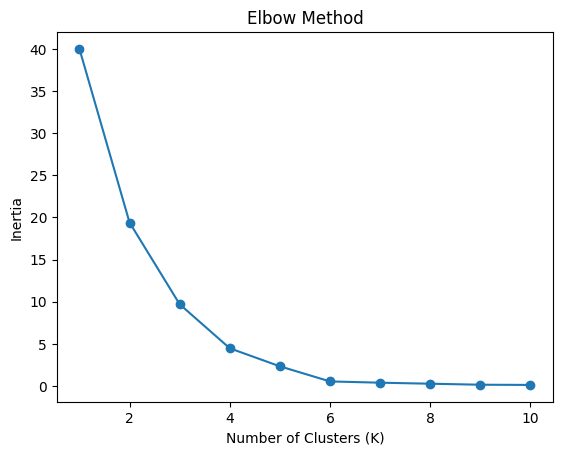


Clustering Evaluation Metrics:
Silhouette Score: 0.7
Davies-Bouldin Index: 0.45
Calinski-Harabasz Score: 42.272


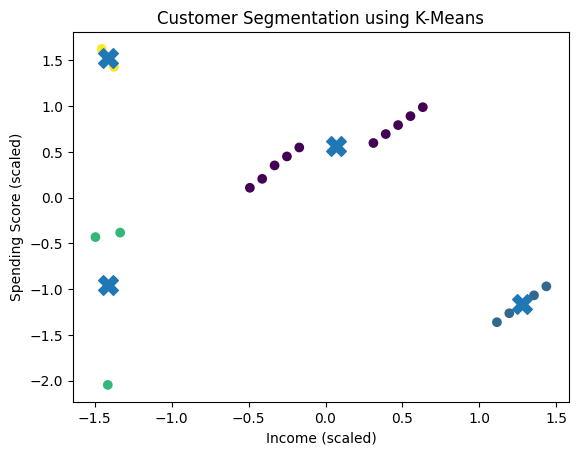


Cluster-wise Mean Values:
         Annual_Income  Spending_Score
Cluster                               
0                 54.0       59.300000
1                 84.0       24.000000
2                 17.0       28.333333
3                 17.0       79.000000


In [1]:
# ============================================
# CUSTOMER SEGMENTATION USING K-MEANS
# WITH CLUSTERING METRICS
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ============================================
# Step 2: Create Dataset (No file needed)
# ============================================

data = pd.DataFrame({
    'Annual_Income': [15,16,17,18,19,40,42,44,46,48,
                      60,62,64,66,68,80,82,84,86,88],

    'Spending_Score': [39,81,6,77,40,50,52,55,57,59,
                       60,62,64,66,68,20,22,24,26,28]
})

print("Dataset:\n")
print(data.head())

# ============================================
# Step 3: Feature Scaling
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# ============================================
# Step 4: Elbow Method (Find optimal K)
# ============================================

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# ============================================
# Step 5: Apply K-Means
# ============================================

k = 4   # Choose based on elbow graph

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

# ============================================
# Step 6: Evaluate Clustering
# ============================================

sil_score = silhouette_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)

print("\nClustering Evaluation Metrics:")
print("Silhouette Score:", round(sil_score, 3))
print("Davies-Bouldin Index:", round(db_index, 3))
print("Calinski-Harabasz Score:", round(ch_score, 3))

# ============================================
# Step 7: Visualization
# ============================================

plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segmentation using K-Means")

plt.show()

# ============================================
# Step 8: Cluster Analysis
# ============================================

print("\nCluster-wise Mean Values:")
print(data.groupby('Cluster').mean())